# Explore Prosody-Acoustic Features in Rhythm Space

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from musiclang.config import DATA_DIR
from musiclang.validation import typology

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the aggregated language features
parquet_path = DATA_DIR / "lang_features.parquet"
df = pd.read_parquet(parquet_path)
df

,delta_c_mean,delta_c_std,delta_v_mean,delta_v_std,duration_s_mean,duration_s_std,f0_max_mean,f0_max_std,f0_mean_mean,f0_mean_std,...,percent_v_mean,percent_v_std,rpvi_c_mean,rpvi_c_std,syllables_per_sec_mean,syllables_per_sec_std,varco_c_mean,varco_c_std,varco_v_mean,varco_v_std
english,0.154873,0.037493,0.073549,0.013440,57.550,0.750000,589.471266,14.499598,162.769209,23.353260,...,36.895816,1.848084,0.144594,0.026966,4.388493,0.425049,92.410645,9.291816,76.560109,8.493857
finnish,0.114546,0.000000,0.063330,0.000000,55.400,0.000000,591.063965,0.000000,139.393577,0.000000,...,39.212828,0.000000,0.098290,0.000000,5.758123,0.000000,92.707759,0.000000,79.751393,0.000000
french,0.094438,0.004192,0.071364,0.010146,57.150,1.783956,593.985672,5.371906,203.294336,33.023753,...,42.659031,0.211985,0.090115,0.005245,5.204809,0.249843,83.147418,2.547492,84.379028,8.313732
german,0.159119,0.002622,0.071156,0.001566,59.400,0.300000,590.478595,8.958353,165.118058,6.231835,...,34.297712,0.689500,0.166696,0.002374,3.880528,0.011181,95.290699,5.240346,81.870857,1.156685
greek,0.138807,0.014575,0.083199,0.013194,54.260,0.821219,576.285417,18.077633,179.274586,31.798874,...,42.514226,3.964582,0.118749,0.011891,4.611400,0.489309,107.489842,15.437453,86.594798,8.197824
italian,0.215427,0.115688,0.084341,0.015965,52.600,6.236586,514.658390,85.783450,175.929428,44.655019,...,35.918700,8.622542,0.167299,0.054919,3.786464,1.135583,116.057478,17.900672,91.528523,5.723994
polish,0.136893,0.035392,0.076154,0.008112,45.625,12.244667,491.249236,96.080545,150.464804,22.676288,...,42.086011,4.036730,0.126635,0.036609,4.661506,1.053607,100.297898,9.317717,79.597261,10.195117
spanish,0.152987,0.024949,0.088603,0.018497,54.300,4.117645,592.606560,9.701320,151.305061,20.978990,...,39.356100,4.925182,0.133296,0.024015,4.645396,0.421687,100.329782,8.222585,90.619773,16.441633


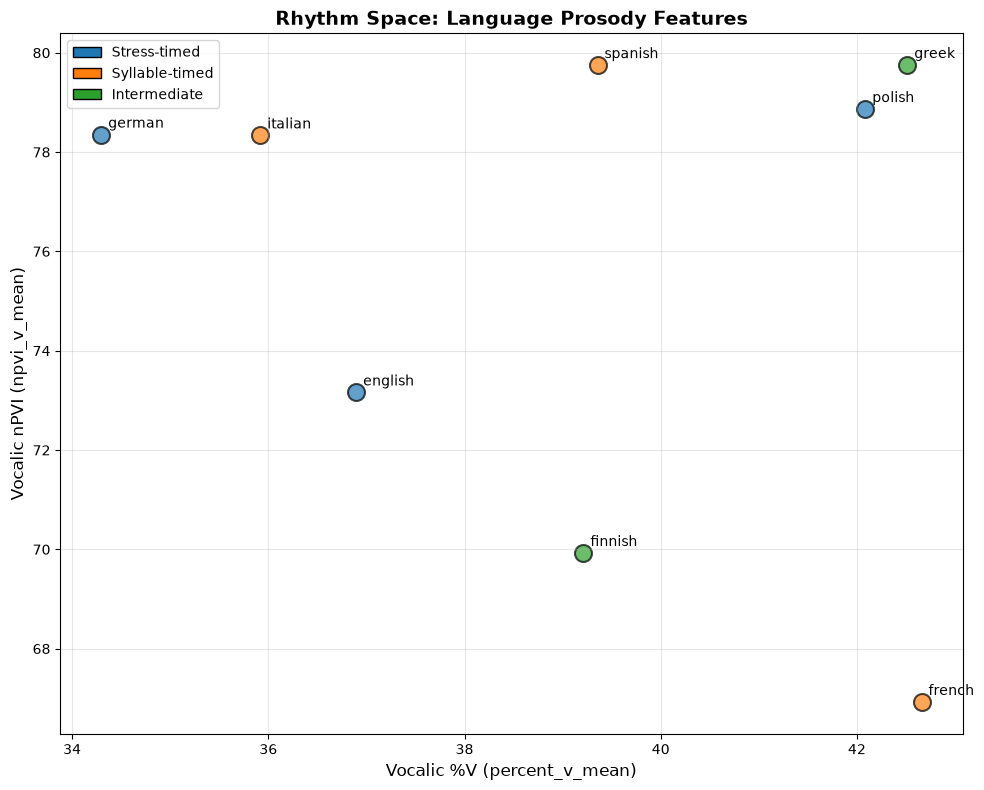

In [3]:
# Plot the rhythm space: vocalic %V vs vocalic nPVI
fig, ax = plt.subplots(figsize=(10, 8))

# Map languages to their rhythm class for coloring
colors = {
    "stress": "#1f77b4",        # blue
    "syllable": "#ff7f0e",      # orange
    "intermediate": "#2ca02c",  # green
}

# Extract and plot points
x = df["percent_v_mean"]
y = df["npvi_v_mean"]
lang_names = df.index

for lang in lang_names:
    rhythm_class = typology.RHYTHM_CLASS.get(lang, "unknown")
    color = colors.get(rhythm_class, "gray")
    ax.scatter(x[lang], y[lang], s=150, alpha=0.7, color=color, edgecolors="black", linewidth=1.5)
    ax.annotate(lang, (x[lang], y[lang]), xytext=(5, 5), textcoords="offset points", fontsize=10)

ax.set_xlabel("Vocalic %V (percent_v_mean)", fontsize=12)
ax.set_ylabel("Vocalic nPVI (npvi_v_mean)", fontsize=12)
ax.set_title("Rhythm Space: Language Prosody Features", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)

# Add legend for rhythm classes
legend_elements = [
    Patch(facecolor=colors["stress"], edgecolor="black", label="Stress-timed"),
    Patch(facecolor=colors["syllable"], edgecolor="black", label="Syllable-timed"),
    Patch(facecolor=colors["intermediate"], edgecolor="black", label="Intermediate"),
]
ax.legend(handles=legend_elements, loc="best", fontsize=10)

plt.tight_layout()
plt.show()

## Observations

**Questions to address in this analysis:**

1. **Typology reproductibility:** Do stress-timed languages (English, German, Polish) tend to cluster higher on the nPVI axis compared to syllable-timed languages (French, Spanish, Italian)? Is the separation pronounced or weak?

2. **Data quality & coverage:** 
   - Which languages have reliable non-NaN values for both `percent_v_mean` and `npvi_v_mean`? 
   - Are there any obvious outliers or suspiciously extreme values that might indicate radio stream artifacts, station-specific bias, or VAD/feature-extraction edge cases?
   - For which languages did the collection yield few or no usable clips, and what does that suggest about station availability or audio quality in those regions?

3. **Confound risks (Arvaniti concerns):**
   - The `*_std` columns (e.g., `percent_v_std`, `npvi_v_std`) show dispersion across clips within each language. Large disparities could indicate speaker variation, speech-rate effects, or station identity leakage rather than true language-level features.
   - Are there particular languages whose feature vectors are unstable (high std relative to mean), suggesting we need more clips or different stations?

**Write your observations below (replace this text):** Based on the rhythm-space plot and the summary statistics in the dataframe, comment on what you see and what questions it raises for the Feature Exploration cycle.